## **FPU Learned by CombOpNet**


## **I. Setup and Preprocessing**

In [1]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from CombOpNet import * 
import DataGenerator as DG

# Tensowflow version should be 2.13.0 or
# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("*******************************|***************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0. Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()


opt_folder = 'output'
# Create the folder if it doesn't exist
os.makedirs(opt_folder, exist_ok=True)

**********************************************
*                                            *
*    Tensorflow Version: 2.10.0              *
*                                            *
*******************************|***************


### **1.2 Training Data**


#### Create dataset

Guess highest order polynomial: 3


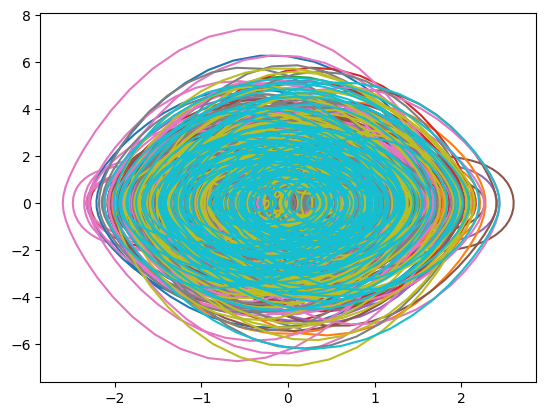

Training input shape: (4000, 10)
Training output shape: (4000, 10)


In [2]:
# Specify the model type
MY_MODEL = 'fermi_pasta_ulam' 
MY_DATA_TYPE = 'float32'

# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  


# Generate data based on the specified model type
num_oscillator = 10  # You can change this value to your desired number of elements
# Generate N random numbers from a normal distribution (mean=0, std=1)
x0 = np.random.uniform(-1.0, 1.0, num_oscillator)
data_initial_conditions = DG.DataGenerator.generate_initial_conditions_by_adding_dx(num_oscillator,x0, 1) #np.random.normal(1, 2, LORENZ96_DIM

data_T =  200.0       # Length of the data (T)
data_dt = 0.05       # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions,T=data_T, dt=data_dt, derivative_mode="exact")
t_arr, x_train, dx_train, guess_highest_order_polynomial = myDG.generate_dataset_by_model_name(MY_MODEL, method="BDF")

print("Guess highest order polynomial:", guess_highest_order_polynomial)
#plot x_train and dx_train
import matplotlib.pyplot as plt
plt.plot(x_train, dx_train)
plt.show()

#Shuffle data
training_input, training_output = x_train[:,:num_oscillator], dx_train[:,num_oscillator:num_oscillator*2]
# Optionally, save a copy of the training input for simulation
training_input_for_sim = training_input.copy() # Saving a copy of training input for simulation (Before shuffling)

training_input, training_output = myDG.shuffleData(training_input, training_output)

print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

### **1.3 Hyperparameters**


In [3]:
# Set mini-batch size
MINI_BATCH_SIZE = 64
learning_rate = 0.01

### **1.4 Model Architecture Definitions**


**CombOpNet Parameters**

In [4]:
# Assign dim to be the 2nd dimension of the training data (number of input variables, including the added constant 1)
dim = training_input.shape[1] 

# The grid size of each dimension
layer_neuron_nums_per_act_fn = [dim] * guess_highest_order_polynomial
print(layer_neuron_nums_per_act_fn)

[10, 10, 10]


**Create the CombOpNet Model**


In [5]:
my_activation = [lambda x:x]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = CombOpNet(layer_neuron_nums_per_act_fn, 1, 
                     activations=my_activation,
                     weight_initializer=tf.initializers.random_normal(stddev=0.001),
                     data_type=MY_DATA_TYPE,
                     name='CombOpNet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)

def reinitialize_model_weights(model):
    if hasattr(model.layers[1], 'reinitialize_weights'):
            model.layers[1].reinitialize_weights()
    else:
        print("CombOpNet does not have a reinitialize_weights() function.")

c:\Users\sxing\anaconda3\envs\tf\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


## **II. Model and Training Preparation**

### **2.1 Loss Function**

In [7]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)

from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [8]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Defining the Training Loop**

In [9]:
import time
np.set_printoptions(threshold=np.inf)

# Define a training step function
@tf.function
def train_step(model, optimizer, loss_fn, inputs, targets, binary_mask):        
    with tf.GradientTape() as tape:
        # Generate predictions and calculate loss
        predictions = model(inputs, training=False)
        loss = loss_fn(targets, predictions)   
        
    # Calculate gradients and update model weights
    gradients = tape.gradient(loss, model.trainable_variables)        

    # Assuming binary_masks_ones is a list of binary masks created for each trainable variable
    masked_gradients = [tf.multiply(grad, mask) for grad, mask in zip(gradients, binary_mask)]

    optimizer.apply_gradients(zip(masked_gradients, model.trainable_variables))

    return loss

# Define a validation step function
@tf.function
def val_step(model, loss_fn, inputs, targets):
    # Generate predictions and calculate loss for validation data
    predictions = model(inputs, training=False)
    # predictions = model(inputs, training=False) 
    v_loss = loss_fn(targets, predictions)
    # Record the validation loss
    return v_loss   

def CombOPNet_fit_w_pruning(
    model,              # TensorFlow model to be trained
    training_input,     # Input features for training
    training_output,    # Target outputs for training
    batch_size,         # Number of samples per batch of computation
    validation_split,   # Fraction of data to be used as validation set
    epochs,             # Number of complete passes through the training dataset
    optimizer,          # Optimization algorithm for updating weights
    loss_fn,            # Loss function to measure model's performance
    pruning_schedule,   # Pruning schedule for gradually increasing the sparsity level
    data_type='float32',    # Data type of the tensors (default: 'float32')
    callbacks=None,         # List of callbacks for custom actions at various stages of training
    early_stopping_loss_threshold=0,       # Threshold for early stopping based on training and validation loss
    verbose=0               # Verbosity mode (0 = silent, 1 = progress bar, etc.)
):
    # Cast the training input and output to the specified data type
    training_input = tf.cast(training_input, data_type)
    training_output = tf.cast(training_output, data_type)

    # Shuffle and batch the dataset, then split it into training and validation sets
    full_dataset = tf.data.Dataset.from_tensor_slices((training_input, training_output)).shuffle(buffer_size=1024)
    total_samples = training_input.shape[0]
    train_samples = int(total_samples * (1 - validation_split))
    
    # Apply the data type casting for each batch in the datasets
    train_dataset = full_dataset.take(train_samples).batch(batch_size).map(lambda x, y: (tf.cast(x, data_type), tf.cast(y, data_type)))
    val_dataset = full_dataset.skip(train_samples).batch(batch_size).map(lambda x, y: (tf.cast(x, data_type), tf.cast(y, data_type)))

    # Initialize metrics for tracking training and validation loss
    train_loss = tf.keras.metrics.Mean(name='train_loss', dtype=data_type)
    val_loss = tf.keras.metrics.Mean(name='val_loss', dtype=data_type)
    
    # Parameters initialization
    binary_mask = [tf.ones_like(var) for var in model.trainable_variables]

    def generate_binary_mask_and_prune_weight(model, pruning_weight_threshold):
        binary_masks = []  # Initialize list to hold binary masks
        
        # Iterate over each variable to apply the pruning threshold and generate masks
        for var in model.trainable_variables:
            # Generate a binary mask where weights above the PRUNING_WEIGHT_THRESHOLD are marked with 1, others with 0
            mask = tf.cast(tf.abs(var) >= pruning_weight_threshold, var.dtype)

            # Update the mask at position (0, 0) to be 1 using tf.tensor_scatter_nd_update (To Avoid the constant term being pruned)
            indices = tf.constant([[0, 0]])  # Specify the indices to update
            updates = tf.constant([1], dtype=mask.dtype)  # Specify the value to update
            mask = tf.tensor_scatter_nd_update(mask, indices, updates)

            binary_masks.append(mask)  # Add the generated mask to the list            

            # Apply mask to modify weights by setting weights below PRUNING_WEIGHT_THRESHOLD to zero
            modified_weight = var * mask
            var.assign(modified_weight)            
        return binary_masks

    # Prepare a dictionary to track the training history
    history = {'loss': [], 'val_loss': []}

    # Before the training loop starts
    if callbacks:
        for callback in callbacks:
            # Assign the model to the callback
            callback.set_model(model)

            # Manually setting params before calling any methods that might depend on them
            callback.params = {
                'epochs': epochs,  # Number of epochs
                # You can add more parameters here as needed
            }

            # Now call on_train_begin with all properties set
            callback.on_train_begin(logs={'loss_threshold': early_stopping_loss_threshold})

    training_start_time = time.time()
    # Execute the training loop
    for epoch in range(epochs):
        # Notify callbacks that the epoch has started
        if callbacks:
            epoch_logs = {}
            for callback in callbacks:
                callback.on_epoch_begin(epoch, logs=epoch_logs)

        if verbose: 
            eopoch_start_time = time.time()

        # Reset state of metrics at the start of each epoch
        train_loss.reset_states()
        val_loss.reset_states()

        # Retrieve the current pruning schedule threshold
        current_pruning_threshold = pruning_schedule[epoch]
        binary_mask = generate_binary_mask_and_prune_weight(model, current_pruning_threshold)
        
        layer_losses_sum = None
        layer_indices = [i for i, layer in enumerate(model.layers) if layer.trainable]
        # Process each batch in the training dataset
        for train_inputs, train_targets in train_dataset:           
            loss = train_step(model = model, 
                            optimizer = optimizer, 
                            loss_fn = loss_fn,
                            inputs = train_inputs, 
                            targets = train_targets, 
                            binary_mask = binary_mask)    
            # Record the loss
            train_loss(loss)

        # Process each batch in the validation dataset
        for val_inputs, val_targets in val_dataset:
            v_loss = val_step(model = model, 
                                loss_fn = loss_fn,
                                inputs = val_inputs, 
                                targets = val_targets)
            val_loss(v_loss)

        # Append the average losses for this epoch to the history
        history['loss'].append(train_loss.result().numpy())
        history['val_loss'].append(val_loss.result().numpy())
        #calculate the average of val_loss
        
        # Current Losses
        current_train_loss = train_loss.result().numpy()
        current_val_loss = val_loss.result().numpy()

        # Notify callbacks that the epoch has ended
        epoch_logs = {'loss': current_train_loss, 'val_loss': current_val_loss}
        if callbacks:
            for callback in callbacks:
                callback.on_epoch_end(epoch, logs=epoch_logs)
    
        if verbose:
            epoch_time = time.time() - eopoch_start_time
            total_layers = len(model.layers)
            trainable_layer_count = sum(1 for layer in model.layers if layer.trainable)
            #print(f"Epoch {epoch + 1:3.0f}:"
            #    f"  Train Loss: {current_train_loss:4.3e}"
            #    f",  Validation Loss: {current_val_loss:4.3e}"
            #    f",  Trainable Layers ({trainable_layer_count}/{total_layers})"
            #    f",  Epoch Time: {epoch_time:.2f}s"  
            #    f",  Current Pruning Threshold: {current_pruning_threshold:.5g}")    
            
        if model.stop_training: # Stop training if all the layers are untrianable
            break   

        # Check for early stopping
        if current_val_loss < early_stopping_loss_threshold:
            print(f"Early stopping at epoch {epoch+1} as train loss {current_val_loss:.8f} is below the threshold {early_stopping_loss_threshold:.8f}")
            break


    # After the training loop ends
    training_time = time.time() - training_start_time
    #print(f'Traininng Stopped. Time elapsed: {training_time:.2f}s')
    if callbacks:
        for callback in callbacks:
            callback.on_train_end(logs={'final_loss': current_train_loss, 'final_val_loss': current_val_loss})
    

    # Return the history containing training and validation losses
    return history

## **III.Training the Model**

#### **Pruning Schedule**

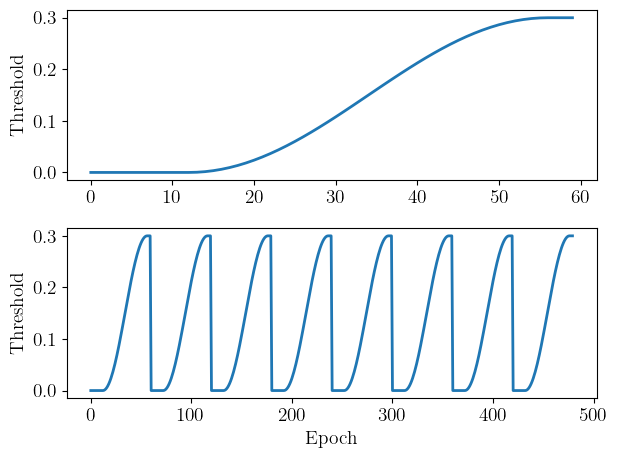

In [10]:
PRUNING_WEIGHT_THRESHOLD = 0.3 #Threshold for 10D Lorenz 96 model. Uses linear prune schedule
N_PERIODS = 8
PRUNING_EPOCHS_PER_PERIOD = 60
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_schedule as ps

# Define the pruning schedule
pruning_schedule = ps.pruning_schedule_ramp(maximum_threshold=PRUNING_WEIGHT_THRESHOLD, 
                                                    steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                                                    num_periods=N_PERIODS, 
                                                    zero_percentage=0.20,
                                                    show_plot=True)

In [1]:
#Setup
callbacks = []

EARLY_STOPPING_LOSS_THRESHOLD = 1e-8   # Threshold for early stopping (Layer Based)

training_histories = []
weights_list = []

## **IV. Training the Model**

In [12]:
#change 0 to a other number if you want to start training from other dimensions
import time

start_time = time.time()

for i in range(0, training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    reinitialize_model_weights(model)
    output = training_output[:, i:i+1]

    history = CombOPNet_fit_w_pruning(
        model,                   # Model to train
        training_input,             # Input data for training
        output,                     # Output data for training
        batch_size=MINI_BATCH_SIZE, # Number of samples per gradient update
        validation_split=0.20,      # Fraction of the training data to be used as validation data
        epochs=round(NUM_EPOCHS),   # Number of times the entire training dataset is passed through the model
        optimizer=my_optimizer,     # Optimizer to use for training
        pruning_schedule = pruning_schedule, # Pruning schedule for gradually increasing the sparsity level
        loss_fn=loss_fn,            # Loss function to use for training
        data_type=MY_DATA_TYPE,     # Data type to use for training
        callbacks= callbacks,       # List of callbacks to apply during training
        early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,# Threshold for early stopping (Layer Based)
        verbose=1                   # Hide the epoch steps
    )
    
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([model.get_layer('CombOpNet').get_weights()])
    #save model weights
    #save_folder = './saved_model'
    #os.makedirs(save_folder, exist_ok=True)
    #model.save_weights(os.path.join(save_folder,f"Lorenz_96_model_weights_dim{i}.h5"))
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.2f}s")

Training dimension 1...
Early stopping at epoch 47 as train loss 0.00000000 is below the threshold 0.00000001
Training dimension 2...
Early stopping at epoch 81 as train loss 0.00000000 is below the threshold 0.00000001
Training dimension 3...
Early stopping at epoch 107 as train loss 0.00000000 is below the threshold 0.00000001
Training dimension 4...
Early stopping at epoch 107 as train loss 0.00000001 is below the threshold 0.00000001
Training dimension 5...
Early stopping at epoch 159 as train loss 0.00000001 is below the threshold 0.00000001
Training dimension 6...
Early stopping at epoch 103 as train loss 0.00000000 is below the threshold 0.00000001
Training dimension 7...
Early stopping at epoch 50 as train loss 0.00000001 is below the threshold 0.00000001
Training dimension 8...
Early stopping at epoch 87 as train loss 0.00000001 is below the threshold 0.00000001
Training dimension 9...
Early stopping at epoch 54 as train loss 0.00000001 is below the threshold 0.00000001
Traini

## **IV. Results**

### **Coefficient Reconstructor (CombOpNet)**



#### `generate_set_labels`

In [13]:
def generate_set_labels(N):
    return ['Constant'] + [f'x{i}' for i in range(1, N+1)]

#### `coefficient_reconstruction`


In [14]:
def coefficient_reconstruction(dim_index,
                                weights, 
                                minimum_coefficient_threshold = 1e-5,
                                coefficient_output_digits = 10, 
                                enable_coefficient_sorting = False):
    
    max_neurons = max(max(len(layer) for layer in combopnet) for combopnet in weights)
    
    labels = generate_set_labels(max_neurons - 1) # number of states = number of neurons - 1

    def explore_path(combopnet_index, layer, neuron, weight_product, label_counts, non_zero_paths):
        """
        Recursively explores non-zero paths in a neural network.
        """
        if layer == len(weights[combopnet_index]) - 1:
            non_zero_paths.append((label_counts, weight_product))
            return

        for next_neuron, weight in enumerate(weights[combopnet_index][layer][neuron]):
            if abs(weight) <= 1e-15:
                # Skip recursion if the weight is zero (if one weight is zero, the whole path will be eliminated)
                continue  
            new_weight_product = weight_product * weight
            next_label_counts = label_counts.copy()
            next_label_counts[labels[next_neuron]] = next_label_counts.get(labels[next_neuron], 0) + 1
            explore_path(combopnet_index, layer + 1, next_neuron, new_weight_product, next_label_counts, non_zero_paths)
    
    #beginning of the algorithm
    all_combopnet_products = []
    for combopnet_index, _ in enumerate(weights):
        non_zero_paths = []
        #collect all non-zero paths
        for neuron_index in range(len(weights[combopnet_index][0])):
            label_counts = {labels[neuron_index]: 1}
            explore_path(combopnet_index, 0, neuron_index, 1, label_counts, non_zero_paths)
        
        #sum up the products with identical composite nonlinear/linear terms
        combopnet_products = {}
        for label_counts, weight_product in non_zero_paths:
            label_counts_key = frozenset(label_counts.items())
            if label_counts_key in combopnet_products:
                combopnet_products[label_counts_key] += weight_product
            else:
                combopnet_products[label_counts_key] = weight_product
        
        #remove the negligible composite terms
        combopnet_products = {k: v for k, v in combopnet_products.items() if abs(v) >= minimum_coefficient_threshold}
        
        if enable_coefficient_sorting:
            #sort the composite terms by their absolute values
            sorted_combopnet_products = dict(sorted(combopnet_products.items(), key=lambda item: abs(item[1]), reverse=True))
        else:
            sorted_combopnet_products = combopnet_products

        all_combopnet_products.append(sorted_combopnet_products)

    #output formatting
    labeled_all_combopnet_products = []
    for combopnet_index, sorted_combopnet_products in enumerate(all_combopnet_products):
        combopnet_product_strings = []
        for key, value in sorted_combopnet_products.items():
            labels_list = []
            only_constant = len(key) == 1 and any(label == 'Constant' for label, _ in key)
            
            for label, count in sorted(key):
                if label == 'Constant' and len(key) > 1:
                    continue
                if label != 'Constant' and count > 1:
                    labels_list.append(f"{label}^{count}")
                elif label == 'Constant' or count == 1:
                    labels_list.append(label if label != 'Constant' else '')
            
            label_str = '*'.join(filter(None, labels_list))
                        
            # Apply coefficient threshold if enabled
            formatted_value = f"{abs(value):.{coefficient_output_digits}g}"

            term_str = label_str if formatted_value == '1' else f"{formatted_value}*{label_str}" if not only_constant else formatted_value if formatted_value != '1' else ''
            sign = '+' if value >= 0 else '-'
            if combopnet_product_strings or value < 0:
                term_str = f" {sign} {term_str}"
            else:
                term_str = term_str
            combopnet_product_strings.append(term_str)

        formatted_output = ''.join(combopnet_product_strings)
        layer_prefix = f"(x{combopnet_index+dim_index+1})'= "
        full_output = layer_prefix + formatted_output
        labeled_all_combopnet_products.append(full_output)

    return labeled_all_combopnet_products

### **Identified Model**

In [15]:
for i in range(len(weights_list)):
    path_products = coefficient_reconstruction(i,weights_list[i], 
                                            minimum_coefficient_threshold = 1e-2,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")


(x1)'=  - 2.000178188*x1 + 1.000126929*x2 - 1.399718722*x1^3 + 2.099418623*x1^2*x2 - 2.099619584*x1*x2^2 + 0.6998941377*x2^3
(x2)'= 1.00006396*x1 - 2.000141156*x2 + 1.000117854*x3 + 0.6999493668*x1^3 - 2.099725429*x1^2*x2 + 2.099653835*x1*x2^2 - 1.399730956*x2^3 + 2.099495068*x2^2*x3 - 2.099663049*x2*x3^2 + 0.6999150374*x3^3
(x3)'= 1.000174341*x2 + 0.6998334803*x2^3 - 2.099393359*x2^2*x3 + 2.099167593*x2*x3^2 - 2.000259756*x3 - 1.399588254*x3^3 + 2.099503724*x3^2*x4 - 2.099792621*x3*x4^2 + 1.000131755*x4 + 0.699968926*x4^3
(x4)'= 1.000045205*x3 - 2.000230023*x4 + 1.0001917*x5 + 0.6999182946*x3^3 - 2.099546081*x3^2*x4 + 2.099238202*x3*x4^2 - 1.399561384*x4^3 + 2.099449074*x4^2*x5 - 2.099731009*x4*x5^2 + 0.6999009117*x5^3
(x5)'= 1.000013571*x4 + 0.7000006283*x4^3 - 2.099993435*x4^2*x5 - 2.000164441*x5 + 2.100003103*x4*x5^2 - 1.399779978*x5^3 + 2.099444717*x5^2*x6 - 2.099479339*x5*x6^2 + 1.000164809*x6 + 0.6998253095*x6^3
(x6)'= 1.000118554*x5 - 2.000053523*x6 + 0.9999831068*x7 + 0.699943